--> STEP 1: Please click 'Choose Files' and select your CSV file.


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

✅ File uploaded successfully: WA_Fn-UseC_-Telco-Customer-Churn.csv

--- Data Overview ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No  

/tmp/ipykernel_453/3719621273.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
/tmp/ipykernel_453/3719621273.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Churn'], ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_453/3719621273.py:74: UserWarning: set_ticklabels() should only be use

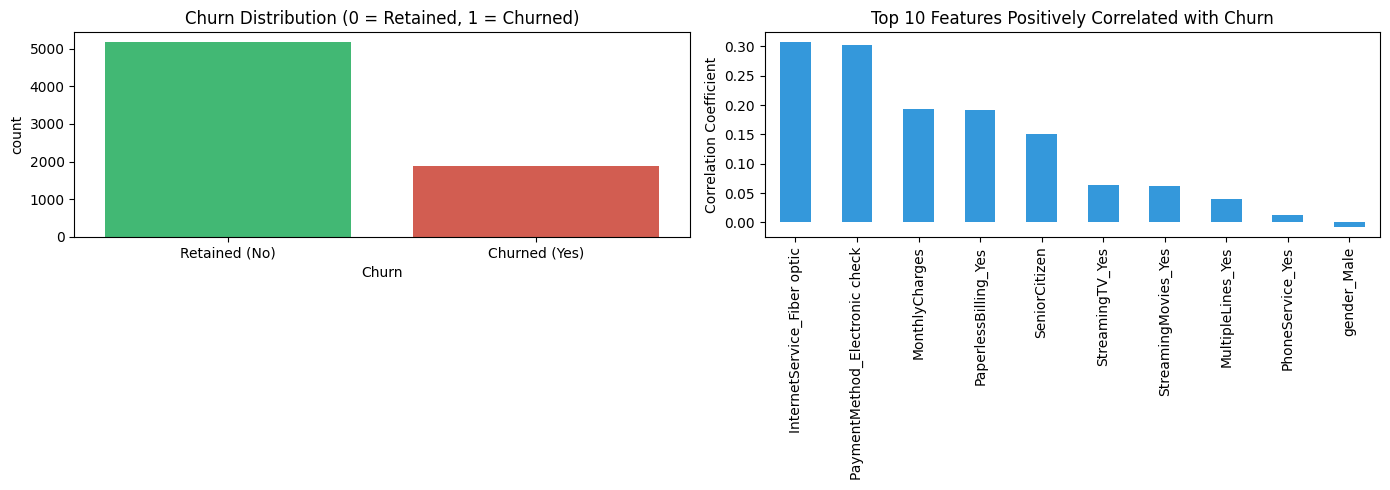


--> STEP 4: Training Models & Computing Performance...

             FINAL MODEL METRICS SUMMARY             
         Model Name Accuracy Recall  ROC-AUC Score
Logistic Regression   80.70% 56.68%         0.8416
      Random Forest   78.64% 49.20%         0.8251
            XGBoost   77.43% 50.27%         0.8186


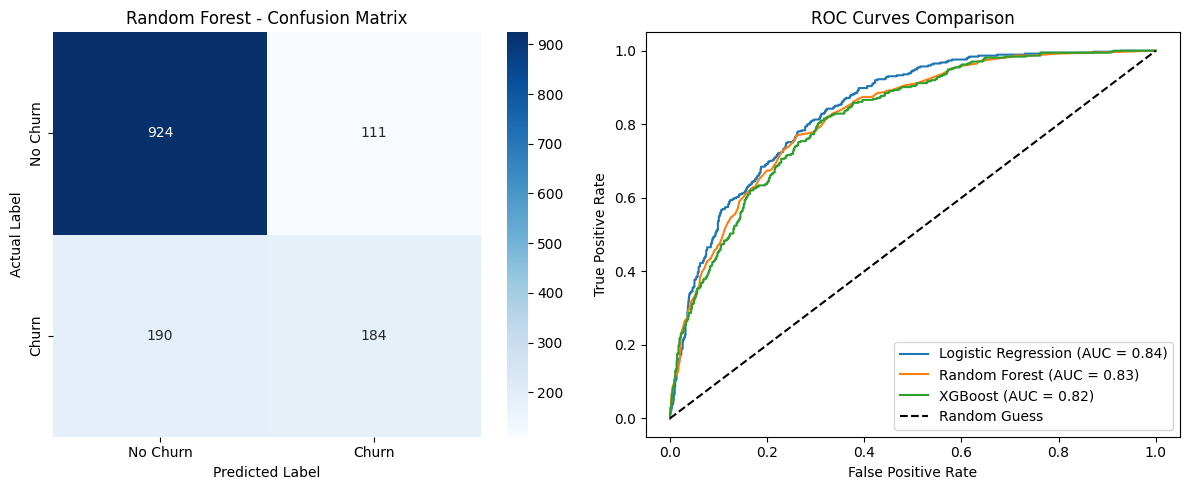


🎉 ALL DONE! Your output graphs and performance table are ready to submit!


In [1]:
# =========================================================
# PROJECT 1: CUSTOMER CHURN PREDICTION PIPELINE (GOOGLE COLAB)
# =========================================================

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# ---------------------------------------------------------
# STEP 1: FILE UPLOAD
# ---------------------------------------------------------
print("--> STEP 1: Please click 'Choose Files' and select your CSV file.")
uploaded = files.upload()

# Automatically detect file name
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded successfully: {filename}")

# Load into Pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("\n--- Data Overview ---")
print(df.head(3))
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ---------------------------------------------------------
# STEP 2: DATA CLEANING & PREPROCESSING
# ---------------------------------------------------------
print("\n--> STEP 2: Cleaning Data & Preprocessing...")

# Drop ID column if present
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (fix space/blank strings)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode Target Variable 'Churn' (Yes -> 1, No -> 0)
if 'Churn' in df.columns:
    if df['Churn'].dtype == 'object':
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for text/categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("✅ Data cleaning & encoding completed!")

# ---------------------------------------------------------
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
print("\n--> STEP 3: Generating Visual Graphs (EDA)...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Class Distribution
sns.countplot(x=df['Churn'], ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (0 = Retained, 1 = Churned)')
axes[0].set_xticklabels(['Retained (No)', 'Churned (Yes)'])

# Plot 2: Top Features Correlated with Churn
churn_corr = df.corr()['Churn'].sort_values(ascending=False).drop('Churn')
churn_corr.head(10).plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Top 10 Features Positively Correlated with Churn')
axes[1].set_ylabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# STEP 4: MODEL TRAINING & EVALUATION
# ---------------------------------------------------------
print("\n--> STEP 4: Training Models & Computing Performance...")

# Feature Matrix and Target Vector
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Classification Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model Name': name,
        'Accuracy': f"{acc*100:.2f}%",
        'Recall': f"{rec*100:.2f}%",
        'ROC-AUC Score': round(auc, 4)
    })

results_df = pd.DataFrame(results)

print("\n" + "="*50)
print("             FINAL MODEL METRICS SUMMARY             ")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

# ---------------------------------------------------------
# STEP 5: CONFUSION MATRIX & ROC CURVE PLOTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot 1: Confusion Matrix for Random Forest
best_rf = models['Random Forest']
rf_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, rf_pred)

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Plot 2: ROC-AUC Comparison Curve
plt.subplot(1, 2, 2)
for name, model in models.items():
    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()

plt.tight_layout()
plt.show()

print("\n🎉 ALL DONE! Your output graphs and performance table are ready to submit!")
